# Getting started with MemsArray object

2023-09-07 22:12:40,924 [INFO]:  .Set beamformer on a 25 MEMs antenna
2023-09-07 22:12:40,925 [INFO]:  .Set beamformer sampling rate on 10000 Hz
2023-09-07 22:12:40,925 [INFO]:  .Set beamformer FFT window size to 256 samples
2023-09-07 22:12:40,926 [INFO]:  .Set beamformer space quantization to [2, 2.1, 0.49504950495049505] locations/meter
2023-09-07 22:12:40,927 [INFO]:  .Set beamformer space size to [5, 5, 2.02] meters
2023-09-07 22:12:40,929 [INFO]:  .Set beamformer sampling rate on 10000 Hz
2023-09-07 22:12:40,930 [INFO]:  .Checking beamformer parameters...
2023-09-07 22:12:40,931 [INFO]:  .[Ready]
2023-09-07 22:12:40,932 [INFO]:  .Beamformer2D Initilization:
2023-09-07 22:12:40,933 [INFO]:   > Found antenna with 25 MEMs microphones
2023-09-07 22:12:40,934 [INFO]:   > FFT window size is 256 samples
2023-09-07 22:12:40,935 [INFO]:   > Time range: [0, 0.0255] s
2023-09-07 22:12:40,936 [INFO]:   > Frequency range: [0, 5000.0] Hz (129 beams)
2023-09-07 22:12:40,937 [INFO]:   > Space qu

available mems number=32
active mems number=32
data=[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
data=[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
data=[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
data=[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
data=[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
data=[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ..

/var/folders/5t/pvxhn0153tg1kdfvfgcwp6_m0000gn/T/ipykernel_10547/2925429624.py:48: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


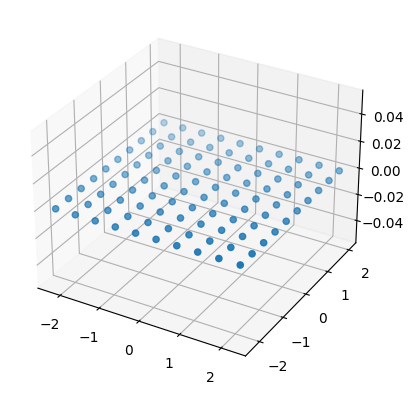

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from megamicros.log import log
from megamicros.core.base import MemsArray
from megamicros.bmf import Beamformer

log.setLevel( "INFO" )

# Declare a 32 MEMs antenna
antenna = MemsArray( available_mems_number=32 )

# verify available mems number
print( f"available mems number={antenna.available_mems_number}" )

# set active mems
antenna.setActiveMems( [i for i in range(32)] )
print( f"active mems number={antenna.mems_number}" )

# iterate over the antenna data stream
for i, data in enumerate( antenna ):
    print( f"data={data}")
    if i > 10:
        break

mems = np.load ('Antenna-square-JetsonNano-0001.npy' )

bmf = Beamformer( 
    mems_position = mems,
    sampling_frequency = 10000,
    window_size = 256,
    space_quantization = [2, 2.1, 1/2.02],
    space_size = [5, 5, 2.02]
)

bmf.setSamplingFrequency( 10000 )

bmf.init()
locations = bmf.getLocations()
print( f"Locations number = {bmf.getLocationsNumber()}" )

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter( locations[:,0], locations[:,1], locations[:,2] )
fig.show()




In [5]:
print(locations)

[[-2.25       -2.26190476  0.        ]
 [-2.25       -1.78571429  0.        ]
 [-2.25       -1.30952381  0.        ]
 [-2.25       -0.83333333  0.        ]
 [-2.25       -0.35714286  0.        ]
 [-2.25        0.11904762  0.        ]
 [-2.25        0.5952381   0.        ]
 [-2.25        1.07142857  0.        ]
 [-2.25        1.54761905  0.        ]
 [-2.25        2.02380952  0.        ]
 [-1.75       -2.26190476  0.        ]
 [-1.75       -1.78571429  0.        ]
 [-1.75       -1.30952381  0.        ]
 [-1.75       -0.83333333  0.        ]
 [-1.75       -0.35714286  0.        ]
 [-1.75        0.11904762  0.        ]
 [-1.75        0.5952381   0.        ]
 [-1.75        1.07142857  0.        ]
 [-1.75        1.54761905  0.        ]
 [-1.75        2.02380952  0.        ]
 [-1.25       -2.26190476  0.        ]
 [-1.25       -1.78571429  0.        ]
 [-1.25       -1.30952381  0.        ]
 [-1.25       -0.83333333  0.        ]
 [-1.25       -0.35714286  0.        ]
 [-1.25        0.11904762